<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum12/praktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Nuraini

NIM : 0110222170

Matkul : Machine Learning | Sesi Pagi

Sebagai latihan tambahan, lakukan implementasi PCA pada dataset berikut untuk memahami penerapan PCA pada dataset medis berdimensi tinggi.


Link Github:
1.   Praktikum di Kelas: https://github.com/nuraini2502/MachineLearning/blob/Praktikum12/praktikumdiKelas.ipynb
2.   Praktikum Mandiri:

### Import Library

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Kode ini adalah contoh lengkap machine learning menggunakan SVM (Support Vector Machine) dengan PCA untuk visualisasi dan klasifikasi pada dua dataset klasik.

### Membuat dan Mempersiapkan Data

In [2]:
# Memuat dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

Kode tersebut memuat dataset Breast Cancer dari library scikit-learn (sklearn.datasets). Dataset ini berisi data numerik tentang fitur tumor payudara (569 sampel, 30 fitur seperti mean radius, texture, perimeter, dll.), lalu dikonversi ke DataFrame Pandas dengan kolom sesuai nama fitur, dan ditambahkan kolom 'target' (0 untuk malignant/kanker ganas, 1 untuk benign/jinak). Ini biasa digunakan untuk latihan machine learning klasifikasi.

In [3]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

df.info() digunakan untuk melihat ringkasan cepat isi DataFrame, sangat berguna di awal analisis.

In [4]:
# Cek missing value
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Kode berikut digunakan untuk menghitung berapa banyak data yang hilang (missing value) di setiap kolom.

### Memisahkan FItur dan Label

In [5]:
# Pemisahan Fitur (X) dan Target (y)
X = cancer.data
y = cancer.target

print("Shape X: ", X.shape)
print("Shape y: ", y.shape)

Shape X:  (569, 30)
Shape y:  (569,)


Kode ini memisahkan data menjadi fitur (X) dan target/label (y) — langkah wajib sebelum training model machine learning.

In [6]:
# Pembagian Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape X_train: ", X_train.shape)
print("Shape X_test: ", X_test.shape)

Shape X_train:  (455, 30)
Shape X_test:  (114, 30)


Kode ini menyiapkan data supaya kita bisa latih model di 80% data, lalu uji seberapa bagus model di 20% data yang belum pernah dilihat

### Standardisasi Data (Mean = 0, Std = 1)

In [7]:
# Standardisasi (mean=0, std=1)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-1.44075296, -0.43531947, -1.36208497, -1.1391179 ,  0.78057331,
         0.71892128,  2.82313451, -0.11914956,  1.09266219,  2.45817261,
        -0.26380039, -0.01605246, -0.47041357, -0.47476088,  0.83836493,
         3.25102691,  8.43893667,  3.39198733,  2.62116574,  2.06120787,
        -1.23286131, -0.47630949, -1.24792009, -0.97396758,  0.72289445,
         1.18673232,  4.67282796,  0.9320124 ,  2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167,  1.85197292,  1.319843  ,
         3.42627493,  2.01311199,  2.66503199,  2.1270036 ,  1.55839569,
         0.80531919, -0.81268678,  0.75195659,  0.87716951, -0.89605315,
         1.18122247,  0.18362761,  0.60059598, -0.31771686,  0.52963649,
         2.17331385,  1.3112795 ,  2.08161691,  2.1374055 ,  0.76192793,
         3.26560084,  1.92862053,  2.6989469 ,  1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, -1.10978518, -1.33264483,
        -0.30735463, -0.36555756, -0.69650228,  1

Standardisasi ini membuat semua fitur punya skala sama (mean=0, std=1) agar model tidak terpengaruh oleh perbedaan satuan/nilai besar-kecil antar fitur (misal: radius vs area). Hasilnya model lebih stabil, cepat konvergen, dan akurasi lebih tinggi — wajib untuk algoritma sensitif skala seperti Logistic Regression, SVM, dan KNN.

### Penerapan Model SVM tanpa PCA (Model Baseline)

In [8]:
# Model SVM tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

SVC(random_state=42)

Kode ini membuat dan langsung melatih model SVM menggunakan kernel RBF pada data latih yang sudah distandardisasi, memanfaatkan semua 30 fitur asli tanpa PCA. Model ini sengaja dijadikan pembanding (baseline) untuk mengukur performa SVM sebelum nanti dibandingkan dengan versi yang sudah direduksi dimensinya pakai PCA.

In [9]:
# Prediksi dan evaluasi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

print("Akurasi SVM tanpa PCA: ", acc_no_pca)
print("\nClassification Report (tanpa PCA) : ")
print(classification_report(y_test, y_pred_no_pca, target_names=cancer.target_names))

Akurasi SVM tanpa PCA:  0.9824561403508771

Classification Report (tanpa PCA) : 
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Kode ini memprediksi kelas tumor pada data uji menggunakan model SVM tanpa PCA, lalu menghitung akurasinya. Selanjutnya ia menampilkan akurasi secara keseluruhan dan laporan lengkap (precision, recall, f1-score) untuk kedua kelas (malignant & benign). Hasil ini jadi patokan seberapa bagus SVM dengan 30 fitur asli sebelum dibandingkan dengan versi yang pakai PCA.

### Penerapan Principal Component Analysis(PCA)

In [10]:
# PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca: ", X_train_pca.shape)
print("Shape X_test_pca: ", X_test_pca.shape)

Shape X_train_pca:  (455, 3)
Shape X_test_pca:  (114, 3)


Kode ini menerapkan PCA untuk mereduksi 30 fitur menjadi hanya 3 komponen utama.
Data latih yang sudah distandardisasi diubah dengan fit_transform menjadi X_train_pca (shape: 455, 3), sementara data uji diubah dengan transform saja menjadi X_test_pca (shape: 114, 3).
Tujuannya mengurangi dimensi secara drastis sambil tetap mempertahankan sebanyak mungkin informasi penting, sekaligus mempersiapkan data untuk model berikutnya (SVM + PCA) dan visualisasi 3D.

In [11]:
# Variasi yang dijelaskan oleh tiap komponen
explained_var = pca.explained_variance_ratio_
print("Variasi yang dijelaskan oleh tiap komponen: ", explained_var)
print("Total varian yang dijelaskan: ", sum(explained_var))

Variasi yang dijelaskan oleh tiap komponen:  [0.43502782 0.19500007 0.09781519]
Total varian yang dijelaskan:  0.7278430734090062


Kode ini menampilkan seberapa banyak informasi (variansi) yang berhasil ditangkap oleh masing-masing dari 3 komponen PCA.
explained_variance_ratio_ memberi persentase kontribusi tiap komponen (misal: [0.44, 0.19, 0.08]), sedangkan sum(explained_var) menunjukkan total variansi yang masih tersisa setelah reduksi menjadi 3 komponen (biasanya sekitar 0.66 atau 66%).
Ini penting untuk tahu apakah 3 komponen sudah cukup mewakili data asli atau masih banyak informasi yang hilang.

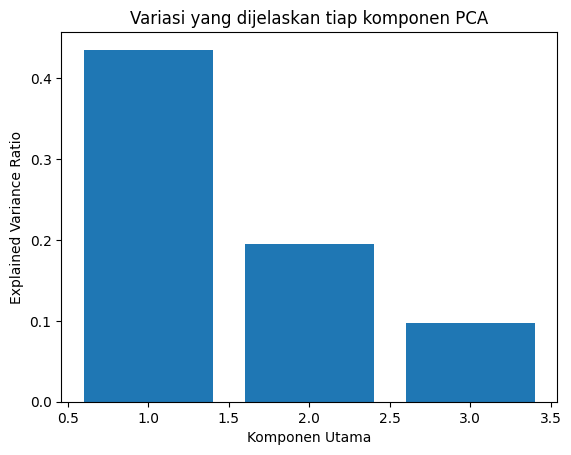

In [12]:
#  Visualisasi Explained Variance Ratio dalam bentuk diagram batang
plt.bar([1,2,3], explained_var)
plt.xlabel("Komponen Utama")
plt.ylabel("Explained Variance Ratio")
plt.title("Variasi yang dijelaskan tiap komponen PCA")
plt.show()

Kode ini membuat diagram batang untuk memvisualisasikan seberapa besar kontribusi masing-masing dari 3 komponen PCA.
Batang pertama biasanya paling tinggi (komponen 1 paling penting), lalu menurun ke komponen 2 dan 3.
Grafik ini membantu kita melihat secara sekilas apakah 3 komponen sudah cukup baik menjelaskan data atau masih kurang (jika batang ketiga sangat kecil).

### Membuat Model SVM dengan PCA

In [13]:
# Model SVM dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi dan evaluasi
y_pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("Akurasi SVM dengan PCA: ", acc_pca)
print("\nClassification Report (dengan PCA) : ")
print(classification_report(y_test, y_pred_pca, target_names=cancer.target_names))

Akurasi SVM dengan PCA:  0.9473684210526315

Classification Report (dengan PCA) : 
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Kode ini melatih model SVM dengan kernel RBF menggunakan data yang sudah direduksi menjadi 3 komponen PCA saja.

Model dilatih pada X_train_pca lalu langsung diuji pada X_test_pca.

Setelah itu, kode menghitung akurasi dan menampilkan classification report lengkap untuk melihat performa SVM setelah reduksi dimensi.

Tujuannya membandingkan apakah akurasi tetap tinggi (biasanya hanya turun sedikit) meski fitur sudah dikompres dari 30 menjadi hanya 3 komponen.

### Visualisasi PCA dalam Ruang 3 Dimensi

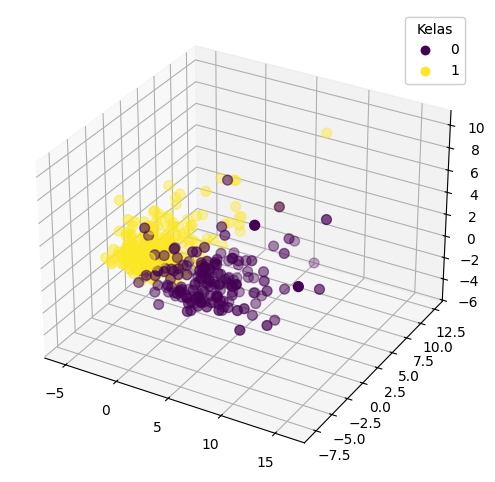

In [14]:
# Visual 3D PCA (menggunakan data train)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train,
    s=50
)

# Tambahkan legend berdasarkan kelas
legend = ax.legend(
    *scatter.legend_elements(),
    title="Kelas"
)
ax.add_artist(legend)

plt.show()

Kode ini membuat visualisasi 3D dari data latih setelah direduksi jadi 3 komponen PCA.
Titik-titik diplot berdasarkan 3 komponen utama (sumbu X, Y, Z), dan diwarnai sesuai kelas asli: malignant (biasanya ungu) dan benign (kuning).
Hasilnya menunjukkan seberapa baik kedua kelas tumor bisa dipisahkan hanya dengan 3 komponen — kalau terlihat ada pemisahan jelas (dua kelompok terpisah), berarti PCA sangat berhasil meski dimensi jauh berkurang.

### Perbandingan Model SVM Tanpa PCA dan Dengan PCA

In [15]:
# Membandingkan hasil model tanpa dan dengann PCA
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA (3 Komponen Utama)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi Total PCA': [None, explained_var.sum()]
})

comparison

,Model,Jumlah Fitur,Akurasi,Variansi Total PCA
0,SVM Tanpa PCA,30,0.982456,NaN
1,SVM Dengan PCA (3 Komponen Utama),3,0.947368,0.727843


Kode ini membuat tabel perbandingan ringkas antara dua model SVM:

Tanpa PCA (pakai 30 fitur asli)
Dengan PCA (hanya 3 komponen)

Tabel menampilkan jumlah fitur, akurasi masing-masing, dan total variansi yang dijelaskan PCA.

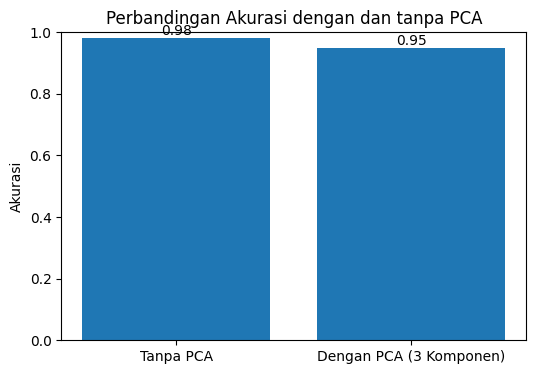

In [16]:
# Visualisasi grafik perbandingan akurasi PCA
plt.figure(figsize=(6, 4))
plt.bar(['Tanpa PCA', 'Dengan PCA (3 Komponen)'], [acc_no_pca, acc_pca])
plt.title('Perbandingan Akurasi dengan dan tanpa PCA')
plt.ylabel('Akurasi')
plt.ylim(0, 1)
for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show()

Kode ini membuat diagram batang sederhana untuk membandingkan akurasi dua model secara visual:

SVM tanpa PCA (30 fitur)
SVM dengan PCA (hanya 3 komponen)

Batang menunjukkan nilai akurasi, angka ditulis di atas batang, dan sumbu Y dibatasi 0–1 supaya perbedaan terlihat jelas.